**Dave**

- MSE
- RMSE
- MAE
- Summary metrics table
- Written conclusion

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor

from preprocessing import df_basic_cleaning_and_split, array_standardise_data, df_feature_constructions
from model1_baseline import train_NN, forward

In [8]:
# Preparing the data
include_added_features = False
if include_added_features:  
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3)
    X_train, X_test = df_feature_constructions(X_train, X_test)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
else:
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3, include_additional_features=False)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
    
# y_train = y_train.flatten()
# y_test = y_test.flatten()

In [9]:
print("Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)")

W1_t, b1_t, w2_t, b2_t, losses = train_NN(X_train, y_train, hidden=64, lr=0.001, iters=10_000)

y_pred_m1, _ = forward(X_test, W1_t, b1_t, w2_t, b2_t)
m1_standard_mse = mean_squared_error(y_test, y_pred_m1)
print(f"Model 1 ran Final Test MSE: {m1_standard_mse:.4f}")

Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)
Model 1 ran Final Test MSE: 0.5111


Training Model 2 (Sklearn MLPRegressor)...


c:\Users\clbir\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1631: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Model 2 ran Final Test MSE: 0.2979


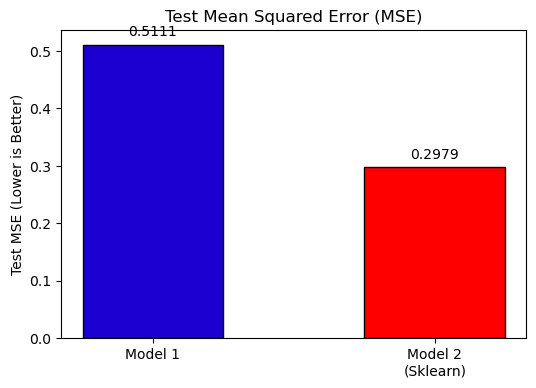

In [10]:
print("Training Model 2 (Sklearn MLPRegressor)...")
clf = MLPRegressor(solver='adam', alpha=1e-5, learning_rate='constant',
                   learning_rate_init=0.001, hidden_layer_sizes=(64,), 
                   random_state=1, max_iter=10000)
clf.fit(X_train, y_train)

y_pred_m2 = clf.predict(X_test)
m2_standard_mse = mean_squared_error(y_test, y_pred_m2)
print(f"Model 2 ran Final Test MSE: {m2_standard_mse:.4f}")

fig, axs = plt.subplots(1, 1, figsize=(6, 4))  # Define axs before using it

bars = axs.bar(['Model 1\n', 'Model 2\n(Sklearn)'], 
               [m1_standard_mse, m2_standard_mse], 
               color=["#1C00D1", "#FF0000"], edgecolor='black', width=0.5)
axs.set_title('Test Mean Squared Error (MSE)', fontsize=12)
axs.set_ylabel('Test MSE (Lower is Better)')
for bar in bars:
    axs.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{bar.get_height():.4f}', ha='center', va='bottom')

plt.show()